# Parte 2 — Random Forest
### Predição de Doença Cardiovascular | Dataset Kaggle "Cardiovascular Disease"

**Escopo desta parte:**
- Mesmo pré-processamento e PCA da Parte 1 (mesmo `random_state=42`)
- Treinamento de **Random Forest** com **Grid Search + Validação Cruzada (StratifiedKFold)**
- Avaliação com métricas adequadas ao problema
- Análise da importância das variáveis originais (não só dos componentes do PCA)

> Notebook independente — pode ser executado sozinho no Google Colab.


## 1. Importação das bibliotecas

In [3]:
# Parte 0 — Importação das bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style("whitegrid")


## 2. Carregamento do dataset

In [4]:
# Parte 1 — Carregamento do dataset "Cardiovascular Disease"
# Fonte: https://www.kaggle.com/datasets/sulianova/cardiovascular-disease-dataset
#
# OPÇÃO A (recomendada no Colab): baixar via kagglehub
# É necessário ter uma conta Kaggle e o arquivo kaggle.json configurado
# (kagglehub pede login/token na primeira execução).

!pip install -q kagglehub

import kagglehub

path = kagglehub.dataset_download("sulianova/cardiovascular-disease-dataset")
print("Dataset baixado em:", path)

csv_path = os.path.join(path, "cardio_train.csv")
df = pd.read_csv(csv_path, sep=";")
print(df.shape)
df.head()


Using Colab cache for faster access to the 'cardiovascular-disease-dataset' dataset.
Dataset baixado em: /kaggle/input/cardiovascular-disease-dataset
(70000, 13)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [ ]:
# OPÇÃO B (alternativa manual): caso prefira, faça upload manual do
# arquivo "cardio_train.csv" (baixado do Kaggle) e descomente as linhas abaixo.

# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv("cardio_train.csv", sep=";")
# df.head()


## 3. Análise exploratória (EDA)

Valores nulos por coluna:
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

Balanceamento da variável-alvo (cardio):
cardio
0    0.5003
1    0.4997
Name: proportion, dtype: float64


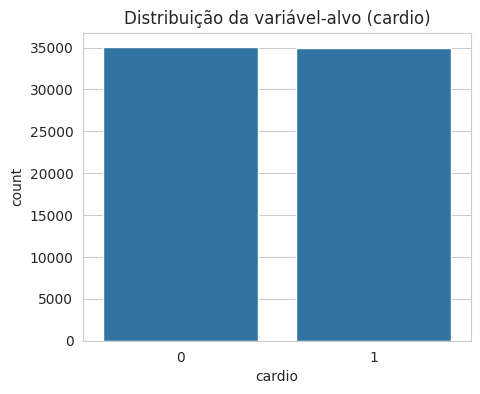

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
# Parte 2 — Análise exploratória rápida (EDA)
print("Valores nulos por coluna:")
print(df.isnull().sum())

print("\nBalanceamento da variável-alvo (cardio):")
print(df["cardio"].value_counts(normalize=True))

plt.figure(figsize=(5,4))
sns.countplot(x="cardio", data=df)
plt.title("Distribuição da variável-alvo (cardio)")
plt.show()

df.describe()


## 4. Pré-processamento

In [6]:
# Parte 3 — Pré-processamento e engenharia de atributos
df = df.drop(columns=["id"])

# Idade estava em dias -> converter para anos
df["age_years"] = (df["age"] / 365.25).round(1)
df = df.drop(columns=["age"])

# Índice de Massa Corporal (IMC), a partir de peso (kg) e altura (cm)
df["bmi"] = df["weight"] / (df["height"] / 100) ** 2

# Pressão de Pulso
df["pulse_pressure"] = df["ap_hi"] - df["ap_lo"]

# Pressão Arterial Média (MAP)
df["map"] = (df["ap_hi"] + 2 * df["ap_lo"]) / 3

# Razão Sistólica/Diastólica
df["bp_ratio"] = df["ap_hi"] / df["ap_lo"]

# Obesidade
df["obesity"] = (df["bmi"] >= 30).astype(int)

# Fatores de Risco
df["risk_score"] = (
    (df["cholesterol"] > 1).astype(int) +
    (df["gluc"] > 1).astype(int) +
    (df["smoke"] == 1).astype(int) +
    (df["alco"] == 1).astype(int) +
    (df["active"] == 0).astype(int) +
    (df["obesity"] == 1).astype(int)
)

# Remoção de valores fisiologicamente impossíveis / outliers grosseiros
# (erros comuns de digitação neste dataset, ver discussões do Kaggle)
df = df[(df["ap_hi"] >= 80) & (df["ap_hi"] <= 250)]
df = df[(df["ap_lo"] >= 40) & (df["ap_lo"] <= 200)]
df = df[df["ap_hi"] >= df["ap_lo"]]
df = df[(df["height"] >= 120) & (df["height"] <= 220)]
df = df[(df["weight"] >= 30) & (df["weight"] <= 200)]

print(f"Formato do dataset após a limpeza: {df.shape}")

X = df.drop(columns=["cardio"])
y = df["cardio"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Treino:", X_train_scaled.shape, " | Teste:", X_test_scaled.shape)


Formato do dataset após a limpeza: (68613, 18)
Treino: (54890, 17)  | Teste: (13723, 17)


## 5. Redução de dimensionalidade (PCA)

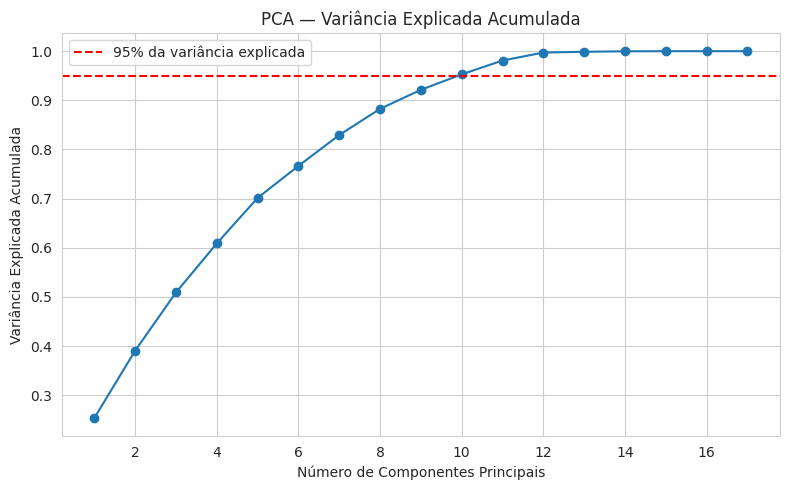

Número de componentes escolhido (>=95% da variância): 10
Formato após PCA -> treino: (54890, 10)  teste: (13723, 10)


In [7]:
# Parte 4 — Redução de dimensionalidade (PCA)
pca_full = PCA(random_state=RANDOM_STATE).fit(X_train_scaled)
variancia_acumulada = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(variancia_acumulada) + 1), variancia_acumulada, marker="o")
plt.axhline(0.95, color="red", linestyle="--", label="95% da variância explicada")
plt.xlabel("Número de Componentes Principais")
plt.ylabel("Variância Explicada Acumulada")
plt.title("PCA — Variância Explicada Acumulada")
plt.legend()
plt.tight_layout()
plt.show()

n_components = int(np.argmax(variancia_acumulada >= 0.95) + 1)
print(f"Número de componentes escolhido (>=95% da variância): {n_components}")

pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Formato após PCA -> treino:", X_train_pca.shape, " teste:", X_test_pca.shape)


## 6. Função de avaliação

In [8]:
# Parte 5 — Função auxiliar de avaliação (métricas adequadas ao problema)
# Problema de classificação binária em saúde -> além da acurácia,
# olhamos recall/precisão/F1 e ROC-AUC (importante p/ dados quase balanceados
# e onde falsos negativos, i.e. deixar de detectar doença, são custosos).

def avaliar_modelo(nome, modelo, X_test, y_test, plotar=True):
    y_pred = modelo.predict(X_test)
    if hasattr(modelo, "predict_proba"):
        y_proba = modelo.predict_proba(X_test)[:, 1]
    else:
        y_proba = modelo.decision_function(X_test)

    metricas = {
        "Modelo": nome,
        "Acuracia": accuracy_score(y_test, y_pred),
        "Precisao": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_proba),
    }

    print(f"\n=== {nome} ===")
    print(classification_report(y_test, y_pred, target_names=["Sem doença", "Com doença"]))

    if plotar:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0])
        axes[0].set_title(f"Matriz de Confusão — {nome}")
        axes[0].set_xlabel("Predito")
        axes[0].set_ylabel("Real")

        RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
        axes[1].set_title(f"Curva ROC — {nome}")
        plt.tight_layout()
        plt.show()

    return metricas

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


## 7. Random Forest — Grid Search + Validação Cruzada

Hiperparâmetros pesquisados:
- `n_estimators`: número de árvores
- `max_depth`: profundidade máxima (controla overfitting)
- `min_samples_split` / `min_samples_leaf`: controle de granularidade das folhas


In [9]:
from sklearn.ensemble import RandomForestClassifier

param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid=param_grid_rf,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1,
)

grid_rf.fit(X_train_pca, y_train)

print("Melhores hiperparâmetros:", grid_rf.best_params_)
print(f"Melhor ROC-AUC médio (validação cruzada): {grid_rf.best_score_:.4f}")


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Melhores hiperparâmetros: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Melhor ROC-AUC médio (validação cruzada): 0.7971


## 8. Avaliação no conjunto de teste


=== Random Forest ===
              precision    recall  f1-score   support

  Sem doença       0.72      0.78      0.75      6934
  Com doença       0.75      0.69      0.72      6789

    accuracy                           0.73     13723
   macro avg       0.73      0.73      0.73     13723
weighted avg       0.73      0.73      0.73     13723



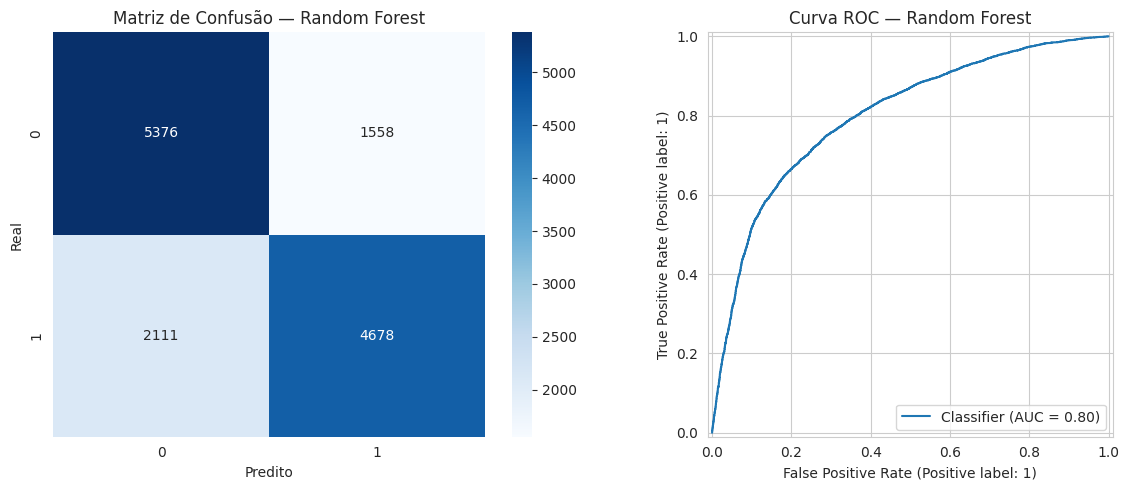

{'Modelo': 'Random Forest',
 'Acuracia': 0.732638635866793,
 'Precisao': 0.7501603592046183,
 'Recall': 0.6890558256002357,
 'F1': 0.7183109404990403,
 'ROC_AUC': np.float64(0.8000939502273461)}

In [10]:
melhor_rf = grid_rf.best_estimator_
resultados_rf = avaliar_modelo("Random Forest", melhor_rf, X_test_pca, y_test)
resultados_rf


## 9. Importância das variáveis originais

Diferente da Regressão Logística, aqui também treinamos uma Random Forest
diretamente sobre as variáveis **originais** (sem PCA) apenas para extrair
a importância de cada atributo original — útil para interpretação clínica,
já que os componentes do PCA não têm significado direto.


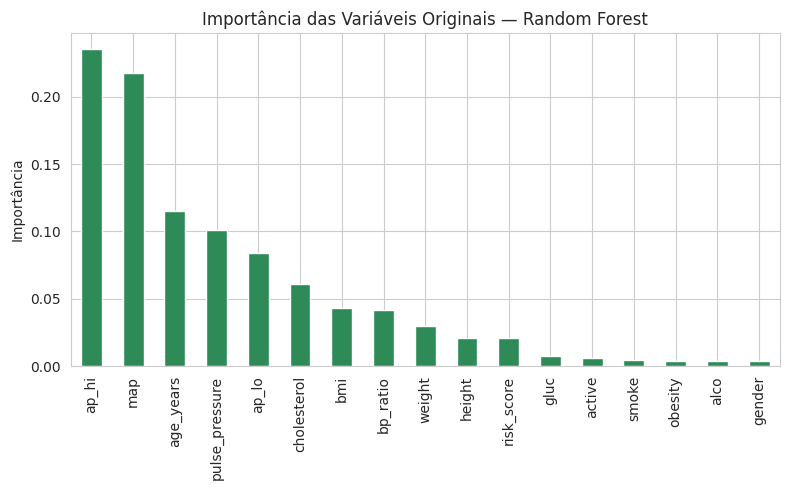

,0
ap_hi,0.235605
map,0.217322
age_years,0.115011
pulse_pressure,0.100969
ap_lo,0.084325
cholesterol,0.061392
bmi,0.042872
bp_ratio,0.041503
weight,0.029523
height,0.021198


In [11]:
rf_interpretavel = RandomForestClassifier(
    **grid_rf.best_params_, random_state=RANDOM_STATE, n_jobs=-1
)
rf_interpretavel.fit(X_train_scaled, y_train)

importancias = pd.Series(rf_interpretavel.feature_importances_, index=X.columns)
importancias = importancias.sort_values(ascending=False)

plt.figure(figsize=(8,5))
importancias.plot(kind="bar", color="seagreen")
plt.title("Importância das Variáveis Originais — Random Forest")
plt.ylabel("Importância")
plt.tight_layout()
plt.show()

importancias


## 10. Salvando os resultados desta parte

In [13]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [14]:
import os
import pickle

# Caminho da pasta no Google Drive
caminho = "/content/drive/MyDrive/IA/Cardiovascular Disease/Resultados"

# Cria a pasta caso ela não exista
os.makedirs(caminho, exist_ok=True)

# Salva o arquivo
with open(f"{caminho}/resultados_rf.pkl", "wb") as f:
    pickle.dump(resultados_rf, f)

print(f"Resultados salvos em {caminho}/resultados_rf.pkl")

Resultados salvos em /content/drive/MyDrive/IA/Cardiovascular Disease/Resultados/resultados_rf.pkl


In [17]:
#salvar modelo
import joblib

caminho_modelos = "/content/drive/MyDrive/IA/Cardiovascular Disease/Modelos/RF"
os.makedirs(caminho_modelos, exist_ok=True)

# salvar o modelo treinado (o "campeão" do GridSearch)
joblib.dump(melhor_rf, f"{caminho_modelos}/modelo_rf.pkl")

# salvar também o scaler e o pca usados no pré-processamento
# (necessários para transformar novos dados da mesma forma que os dados de treino)
joblib.dump(scaler, f"{caminho_modelos}/scaler.pkl")
joblib.dump(pca, f"{caminho_modelos}/pca.pkl")

print(f"Modelo, scaler e PCA salvos em {caminho_modelos}")

Modelo, scaler e PCA salvos em /content/drive/MyDrive/IA/Cardiovascular Disease/Modelos/RF
